# Inital Data Exploration for Kaggle Competition Project. 

### Import libraries

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

### loading and looking at the data

In [3]:
train= pd.read_csv("../train.csv")
test= pd.read_csv("../test.csv")

In [4]:
# basic info
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nFirst few rows:")
print(train.head())
print("\nClass distribution:")
print(train["LABEL"].value_counts())


Train shape: (70317, 3)
Test shape: (17580, 2)

First few rows:
                     ID                                               TEXT  \
0    327995652116863138  Carolyn Baker defines the niche of helping peo...   
1  11848336500074516230  Just getting released from a six month drug re...   
2   8453485550425672763  I was greatly dissappointed when I popped this...   
3  13088897910749354342  This is a film that has garnered any interest ...   
4   4199320520317837800  This is one of the more adorable episodes of t...   

   LABEL  
0      0  
1      1  
2      0  
3      2  
4      1  

Class distribution:
LABEL
0    32289
1    19139
2    18889
Name: count, dtype: int64


### What I can see from this: 

70,317 training examples, 17,580 test examples
3 classes:

Class 0 (not a review): 32,289 -- largest class, about 46%
Class 1 (positive review): 19,139 -- about 27%
Class 2 (negative review): 18,889 -- about 27%



The dataset is imbalanced -- class 0 is almost twice the size of classes 1 and 2. This is important because macro F1 will penalize me if my model ignores the smaller classes.

In [5]:
# print examples from each class
for label, name in zip([0, 1, 2], ["Not a review", "Positive review", "Negative review"]):
    print(f"\n--- {name} (label={label}) ---")
    examples = train[train["LABEL"] == label]["TEXT"].values[:3]
    for ex in examples:
        print(ex[:300])  # first 300 chars
        print()

# text length analysis
train["text_length"] = train["TEXT"].str.len()
print("\nText length stats by class:")
print(train.groupby("LABEL")["text_length"].describe())


--- Not a review (label=0) ---
Carolyn Baker defines the niche of helping people prepare inwardly and in our relationships, for the obvious, huge challenges that face us all in the present and near future.

I was greatly dissappointed when I popped this game into my Xbox. The play was choppy, not smooth at all and far too slow. At times, the players looked cartoon-like. If I were you I would wait for NBA Inside Drive 2002, which comes out on January 22nd. This looks like a much better game and should p

Superbly researched.  Cogent presentation of the third Hundred Days.  Only FDR could convert America from isolation to mobilization so swiftly.


--- Positive review (label=1) ---
Just getting released from a six month drug rehabilitation program and having served his time for dealing cards in illegal gambling card games, Frankie Machine (Frank Sinatra) has high hopes for going clean and finding a new life as a big band drummer. However upon returning to his old crime-ridden 

This is 

### more insights/notes...

Class 0 (not a review) is tricky -- looking at the examples, some of them look like they could be reviews (the Xbox game one especially). This is going to be the hardest classification boundary.
Text length is a strong signal:

Class 0 texts are much shorter on average (median 205 chars)
Classes 1 and 2 are much longer (median ~860-883 chars)
This means text length alone could be a useful feature!

Classes 1 and 2 are very similar in length -- sentiment will be the main differentiator there.

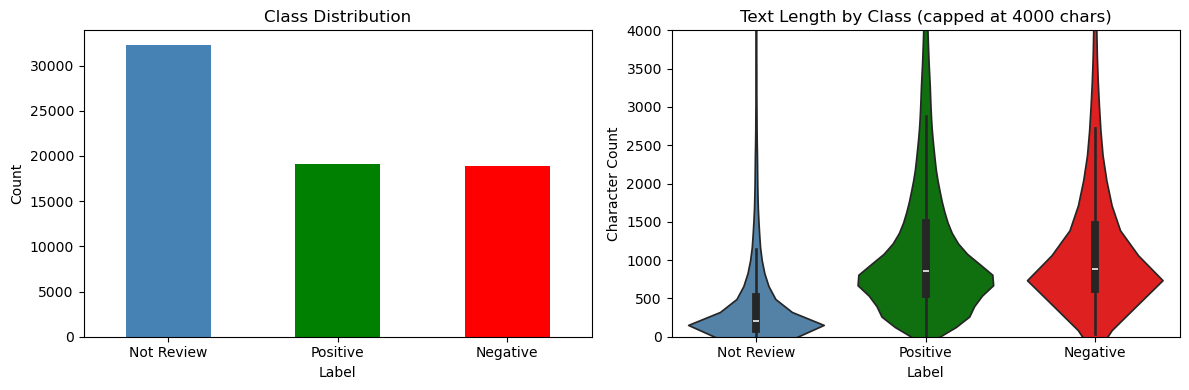

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# class distribution bar chart
train["LABEL"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["steelblue", "green", "red"])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Not Review", "Positive", "Negative"], rotation=0)

# violin plot - fixed warnings
train["LABEL_NAME"] = train["LABEL"].map({0: "Not Review", 1: "Positive", 2: "Negative"})
sns.violinplot(x="LABEL_NAME", y="text_length", data=train, ax=axes[1],
               hue="LABEL_NAME", palette=["steelblue", "green", "red"],
               order=["Not Review", "Positive", "Negative"], legend=False)
axes[1].set_ylim(0, 4000)
axes[1].set_title("Text Length by Class (capped at 4000 chars)")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Character Count")

plt.tight_layout()
plt.savefig("eda_plots.png")
plt.show()

## EDA Observations: 
-Dataset has 70,317 training and 17,580 test examples

-Class imbalance: Not Review (46%), Positive (27%), Negative (27%)

-Text length is a strong differentiating feature -- "Not Review" texts are much shorter (median ~205 chars) vs reviews (median ~860 chars)

-Positive and Negative reviews are very similar in length, so sentiment features will be key for separating those two
